<a href="https://colab.research.google.com/github/liamscanlon5/DS_Analytics_Demand_Estimation_FinalProject/blob/main/Notebook_3_PricingAnalyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

In [6]:
import pandas as pd
from google.colab import files

# Upload the data
uploaded = files.upload()

# Read the data
df = pd.read_csv('air_fryers_clean_brand_year.csv')

# Bring over the price coefficient from Notebook #2
price_coef = -0.037668


results = df.copy()

Saving air_fryers_clean_brand_year.csv to air_fryers_clean_brand_year (1).csv


In [7]:
results = df.copy()
results['demand_slope'] = price_coef * results['brand_share'] * (1 - results['brand_share'])
results['unit_cost'] = results['avg_price'] + results['brand_share'] / results['demand_slope']
results['markup'] = results['avg_price'] - results['unit_cost']
results['average_profit'] = results['brand_share'] * results['markup']

cost_summary = (
    results.groupby('brand')
    .agg(
        avg_unit_cost=('unit_cost', 'mean'),
        avg_markup=('markup', 'mean'),
        avg_share_weighted_profit=('average_profit', 'mean'),
        avg_price=('avg_price', 'mean'),
        avg_rating=('avg_rating', 'mean'),
        avg_brand_share=('brand_share', 'mean'),
    )
    .sort_values('avg_share_weighted_profit', ascending=False)
)

print('Average cost, markup, and profit index by brand')
display(cost_summary)
print(f"Number of brand-years with negative inferred unit cost: {(results['unit_cost'] < 0).sum()}")
display(results[['year', 'brand', 'avg_price', 'brand_share', 'demand_slope', 'unit_cost', 'markup', 'average_profit']].sort_values(['year', 'brand']))

Average cost, markup, and profit index by brand


,avg_unit_cost,avg_markup,avg_share_weighted_profit,avg_price,avg_rating,avg_brand_share
brand,,,,,,
ninja,112.488773,32.853768,6.306035,145.342541,4.742064,0.191567
instant_pot,71.903419,32.557934,6.010201,104.461353,4.559323,0.174921
gowise usa,56.301327,31.153454,4.605721,87.454781,4.576990,0.138005
dash,27.936850,29.542077,2.994344,57.478927,4.476394,0.097862
chefman,61.569736,29.368675,2.820942,90.938411,4.427966,0.095079
ultrean,48.786035,29.328571,2.780838,78.114606,4.672616,0.092369
cuisinart,194.896386,29.050707,2.502974,223.947093,4.438892,0.085787
cosori,86.283579,27.984371,1.436638,114.267950,4.656292,0.048974
nuwave,109.053806,27.970578,1.422845,137.024384,4.389798,0.050559


Number of brand-years with negative inferred unit cost: 0


,year,brand,avg_price,brand_share,demand_slope,unit_cost,markup,average_profit
0,2019,chefman,72.963695,0.076015,-0.002646,44.231920,28.731775,2.184042
1,2019,cosori,159.990000,0.000730,-0.000027,133.422883,26.567117,0.019384
2,2019,cuisinart,229.465274,0.107190,-0.003605,199.730236,29.735039,3.187306
3,2019,dash,55.176333,0.199721,-0.006021,22.003219,33.173114,6.625381
4,2019,gowise usa,83.575551,0.292186,-0.007790,46.068886,37.506665,10.958932
5,2019,instant_pot,78.019945,0.015787,-0.000585,51.046390,26.973556,0.425823
6,2019,ninja,112.158374,0.192624,-0.005858,79.276874,32.881500,6.333767
7,2019,nuwave,151.099937,0.032104,-0.001170,123.671646,27.428291,0.880558
8,2019,oster,191.943688,0.033563,-0.001222,164.473982,27.469706,0.921973
9,2019,ultrean,80.624675,0.050080,-0.001792,52.677351,27.947324,1.399591


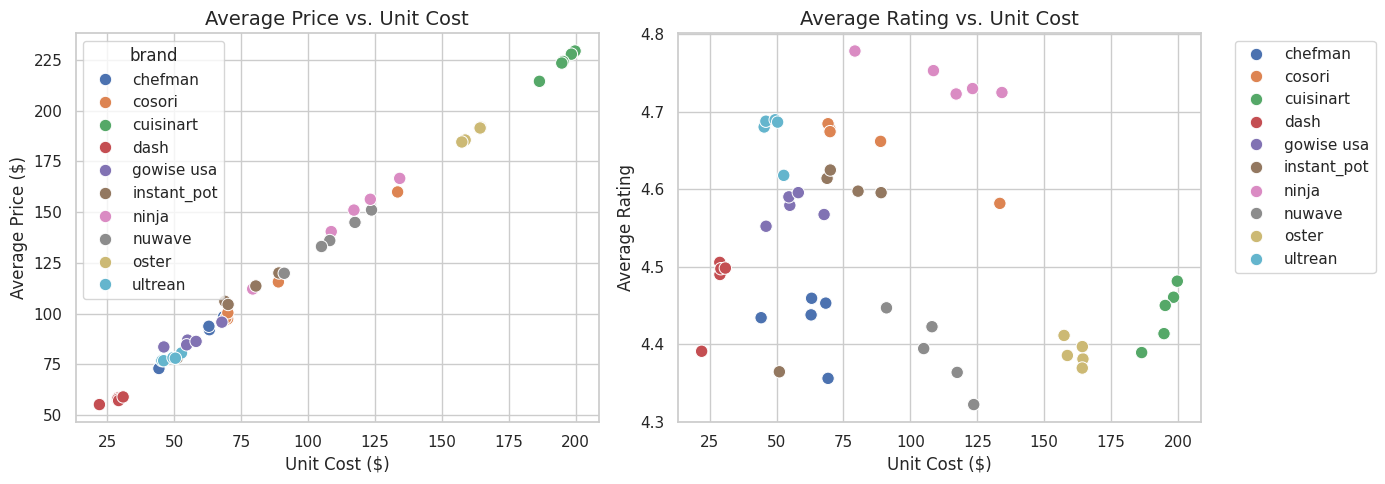

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price vs. Unit Cost
sns.scatterplot(data=results, x='unit_cost', y='avg_price', hue='brand', s=80, ax=axes[0])
axes[0].set_title('Average Price vs. Unit Cost', fontsize=14)
axes[0].set_xlabel('Unit Cost ($)')
axes[0].set_ylabel('Average Price ($)')

# Average Rating vs. Unit Cost
sns.scatterplot(data=results, x='unit_cost', y='avg_rating', hue='brand', s=80, ax=axes[1])
axes[1].set_title('Average Rating vs. Unit Cost', fontsize=14)
axes[1].set_xlabel('Unit Cost ($)')
axes[1].set_ylabel('Average Rating')

# Move legend outside the second plot for better visibility
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

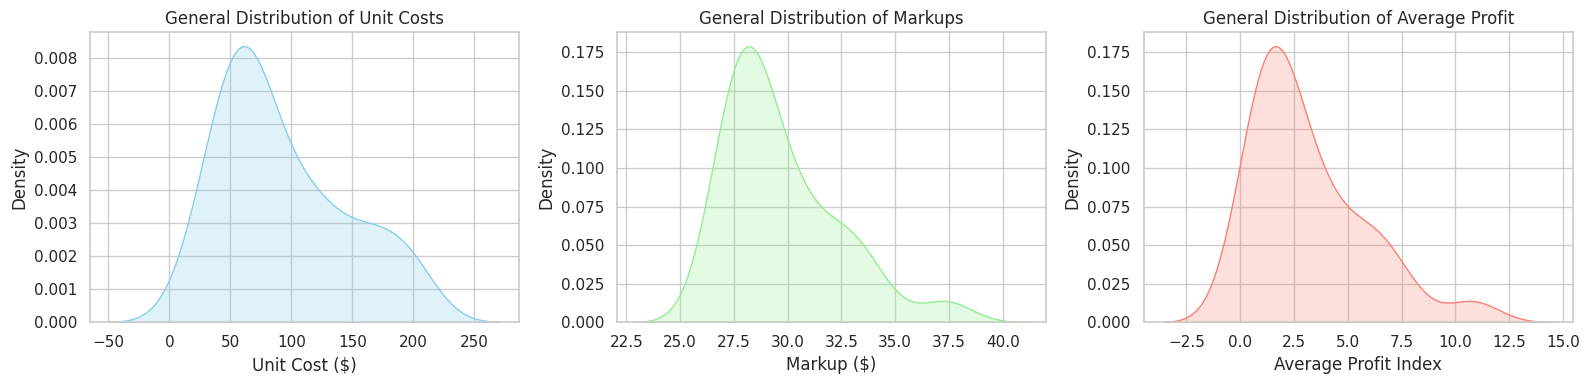

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.kdeplot(data=results, x='unit_cost', fill=True, color='skyblue', ax=axes[0])
axes[0].set_title('General Distribution of Unit Costs', fontsize=12)
axes[0].set_xlabel('Unit Cost ($)')

sns.kdeplot(data=results, x='markup', fill=True, color='lightgreen', ax=axes[1])
axes[1].set_title('General Distribution of Markups', fontsize=12)
axes[1].set_xlabel('Markup ($)')

sns.kdeplot(data=results, x='average_profit', fill=True, color='salmon', ax=axes[2])
axes[2].set_title('General Distribution of Average Profit', fontsize=12)
axes[2].set_xlabel('Average Profit Index')

plt.tight_layout()
plt.show()

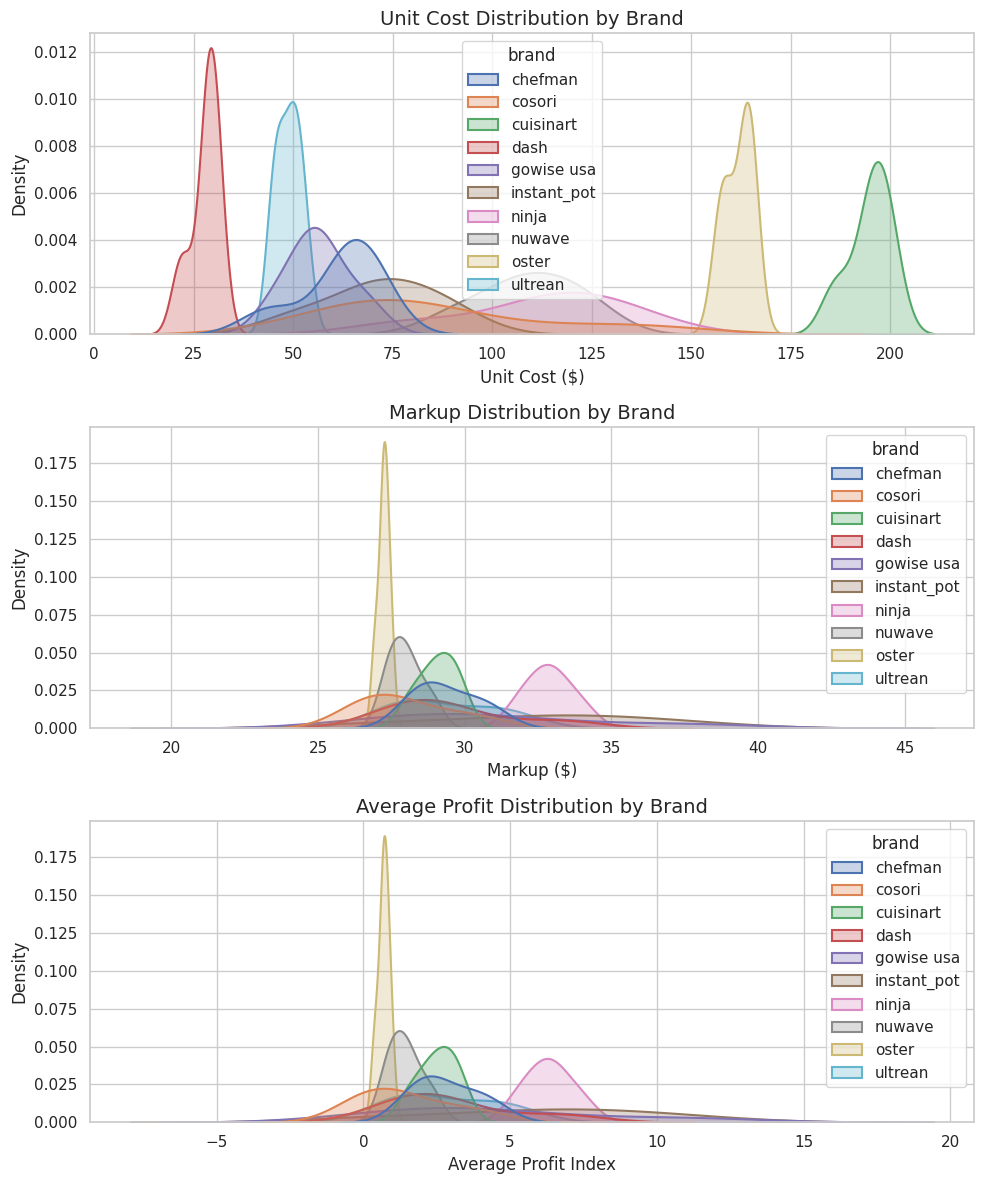

In [10]:
# Create a figure with 3 stacked subplots for brand-specific distributions
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

sns.kdeplot(data=results, x='unit_cost', hue='brand', fill=True, alpha=0.3, linewidth=1.5, ax=axes[0])
axes[0].set_title('Unit Cost Distribution by Brand', fontsize=14)
axes[0].set_xlabel('Unit Cost ($)')

sns.kdeplot(data=results, x='markup', hue='brand', fill=True, alpha=0.3, linewidth=1.5, ax=axes[1])
axes[1].set_title('Markup Distribution by Brand', fontsize=14)
axes[1].set_xlabel('Markup ($)')

sns.kdeplot(data=results, x='average_profit', hue='brand', fill=True, alpha=0.3, linewidth=1.5, ax=axes[2])
axes[2].set_title('Average Profit Distribution by Brand', fontsize=14)
axes[2].set_xlabel('Average Profit Index')

plt.tight_layout()
plt.show()

1. Average unit costs range significantly from roughly 28 (Dash) up to 195 (Cuisinart), and average markups range from about 27 (Oster) to 33 (Ninja).

2. There are 0 brand-years with negative inferred unit costs. This makes sense and indicates that the demand model produced logical and economically realistic cost estimates.

3. Cuisinart and Oster have the highest average unit costs. More expensive products do not have higher consumer satisfaction. The scatter plots show that the highest-rated brands (Ninja and Cosori) sit firmly in the middle of the cost spectrum, while budget brands like Dash achieve average ratings that beat out the most expensive premium options.

4. The kernel density plots show a wide spread for unit costs, and the distributions for markups and average profits are identical in shape. This visualizes a key limitation of our model, which is that it forces both a brand's markup and its total profit to be driven entirely by its market share.

5. Ninja and Instant Pot have the highest share-weighted average profits. The profit kernel density plot shows these two brands extending to the right while most other brands are clustered tightly near the lower end of the index.